In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg
import cartopy.crs as ccrs
from scipy.special import legendre
from scipy import integrate

In [2]:
def align_phases(E1_phi, E1_the, E2_phi, E2_the, E3_phi, E3_the, target_latitude=65, latitudes_lct=None, latitudes_rda=None, m=None):
    """
    Align the phases of three 1D complex eigenfunctions at the specified latitude.

    Parameters:
    E1_phi : ndarray
        First 1D complex array (eigenfunction 1).
    E2_phi : ndarray
        Second 1D complex array (eigenfunction 2).
    E3_phi : ndarray
        Third 1D complex array (eigenfunction 3).
    target_latitude : float, optional
        Latitude at which to align the phase (default is 65°).
    latitudes : ndarray, optional
        1D array of latitudes corresponding to the eigenfunctions (default is None).

    Returns:
    E2_aligned : ndarray
        The second eigenfunction with the phase aligned to the first at the given latitude.
    E3_aligned : ndarray
        The third eigenfunction with the phase aligned to the first at the given latitude.
    """

    # If latitudes are not provided, create a default linear range from -90 to 90
    if latitudes_lct is None:
        latitudes_lct = np.linspace(-90, 90, len(E1_phi))

    # Find the index of the target latitude
    lat_idx_lct = np.argmin(np.abs(latitudes_lct - target_latitude))
    lat_idx_rda = np.argmin(np.abs(latitudes_rda - target_latitude))

    # Calculate the phase of each eigenfunction at the specified latitude
    phase_1 = np.angle(E1_phi[lat_idx_lct])
    phase_2 = np.angle(E2_phi[lat_idx_lct])
    phase_3 = np.angle(E3_phi[lat_idx_rda])  # BEGIN: Added for third eigenfunction

    delta_phi_2 = phase_1 - phase_2
    delta_phi_3 = phase_1 - phase_3  # BEGIN: Added for third eigenfunction

    # Align the second and third eigenfunctions by multiplying them with the complex exponential of the phase difference
    E2_phi_aligned = E2_phi * np.exp(1j * delta_phi_2)
    E2_the_aligned = E2_the * np.exp(1j * delta_phi_2)

    E3_phi_aligned = E3_phi * np.exp(1j * delta_phi_3)  # BEGIN: Added for third eigenfunction
    E3_the_aligned = E3_the * np.exp(1j * delta_phi_3)  # BEGIN: Added for third eigenfunction

    if m == 8:
        E2_phi_aligned = E2_phi_aligned * np.exp(1j * -delta_phi_2)
        E2_the_aligned = E2_the_aligned * np.exp(1j * -delta_phi_2)

        E3_phi_aligned = E3_phi_aligned * np.exp(1j * -delta_phi_3)  # BEGIN: Added for third eigenfunction
        E3_the_aligned = E3_the_aligned * np.exp(1j * -delta_phi_3)  # BEGIN: Added for third eigenfunction

    return E1_phi, E1_the, E2_phi_aligned, E2_the_aligned, E3_phi_aligned, E3_the_aligned  # BEGIN: Updated return statement


In [3]:
f_m1_mag = np.load('/data/seismo/joshin/pipeline-test/local_correlation_tracking/data/eigenfunctions/eigenfunction_m1_-88.0_highlat_anti_hmi_m_720s_dt_1h.npz')
uphi_m1_lct_mag = f_m1_mag['ef_uphi']
uthe_m1_lct_mag = f_m1_mag['ef_uthe']


lats = np.linspace(-90, 90, 73)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.special import legendre
from scipy.stats import chi2

def confidence_level_to_power(conf, B, M, dof):
    """
    confidence level = 1 - FAP
    conf: float
        confidence level from 0 to 1
        conf = 1 - FAP, where
        FAP means false alarm probability or significance level
    B: float
        background power estimated from Lorentian fit
    M: int
        number of frequency bins of concern
    dof: int
        the degrees of freedom of chisquare distribution
    --- example ---
    conf = 0.95
    frng = (nu > fl) & (nu < fh)
    M = frng.sum()
    """
    cdf = conf**(1/M)
    z_conf = chi2.ppf(cdf, df=dof)
    p_conf = z_conf*B/dof
    return p_conf

def power_to_confidence_level(p, B, M, dof):
    """
    Eq. (13.8.7) of Numerical Recipes (3rd edition) says
    FAP \equiv 1 - ( chi2.cdf(z) )^M,
    where FAP means false alarm probability or significance level.
    And confidence level is just 1 - FAP
    """
    return chi2.cdf(p/B*dof, df=dof)**M

def monte_carlo_errorbars(theta, l_discard, fl_discard, num_samples=1000):
    P = np.array([
        np.sqrt((2 * l + 1) / 2) * legendre(l)(np.cos(theta)) for l in l_discard
    ])  # shape (num_l, num_theta)

    samples_real = []
    samples_imag = []
    print(min(l_discard), max(l_discard), len(fl_discard), len(P))
    for _ in range(num_samples):
        phases = np.exp(1j * 2 * np.pi * np.random.rand(len(fl_discard)))
        f_random = np.abs(fl_discard) * phases
        u_sample = np.sum(f_random[:, None] * P, axis=0)
        samples_real.append(np.real(u_sample))
        samples_imag.append(np.imag(u_sample))

    std_real = np.std(samples_real, axis=0)
    std_imag = np.std(samples_imag, axis=0)
    return std_real, std_imag, samples_real, samples_imag



def plot_fl_power(fl_uphi, fl_uthe, l_phi, l_the, m, noise_threshold_uphi, noise_threshold_uthe, l_max_uphi, l_max_uthe_keep):

    # Determine parity labels — parities are complementary between components
    if len(l_phi) > 0:
        if all(l % 2 == 0 for l in l_phi):
            parity_label_phi = r'$\ell$ (even)'
            parity_label_the = r'$\ell$ (odd)'
        elif all(l % 2 == 1 for l in l_phi):
            parity_label_phi = r'$\ell$ (odd)'
            parity_label_the = r'$\ell$ (even)'
        else:
            parity_label_phi = r'$\ell$'
            parity_label_the = r'$\ell$'
    else:
        parity_label_phi = r'$\ell$'
        parity_label_the = r'$\ell$'

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(l_phi, np.abs(fl_uphi)**2, marker='o', linestyle='-', color='blue')
    ax[0].axvline(x=l_max_uphi, color='red', linestyle='--', label=r'Maximum $\ell$ in $u_\phi$')
    ax[0].axvspan(0, l_max_uphi, color='gray', alpha=0.1)
    ax[0].axhline(y=noise_threshold_uphi, color='green', linestyle='--', label=r'90% confidence level')
    ax[0].set_xlabel(parity_label_phi, fontsize=14)
    ax[0].set_ylabel(r'$|f_\ell|^2$', fontsize=14)
    ax[0].set_title(r'$u_\phi$ (m={})'.format(m), fontsize=14)
    ax[0].set_xticks(np.arange(0, max(l_phi)+1, 5))
    ax[0].set_xticklabels(np.arange(0, max(l_phi)+1, 5), fontsize=12)
    ax[0].set_xticks(np.arange(0, max(l_phi)+1, 1), minor=True)
    ax[0].grid(True)
    ax[0].legend()

    ax[1].plot(l_the, np.abs(fl_uthe)**2, marker='o', linestyle='-', color='orange')
    ax[1].axvline(x=l_max_uthe_keep, color='red', linestyle='--', label=r'Maximum $\ell$ in $u_\theta$')
    ax[1].axvspan(0, l_max_uthe_keep, color='gray', alpha=0.1)
    ax[1].axhline(y=noise_threshold_uthe, color='green', linestyle='--', label=r'90% confidence level')
    ax[1].set_xlabel(parity_label_the, fontsize=14)
    ax[1].set_ylabel(r'$|f_\ell|^2$', fontsize=14)
    ax[1].set_title(r'$u_\theta$ (m={})'.format(m), fontsize=14)
    ax[1].set_xticks(np.arange(0, max(l_phi)+1, 5))
    ax[1].set_xticklabels(np.arange(0, max(l_phi)+1, 5), fontsize=12)
    ax[1].set_xticks(np.arange(0, max(l_phi)+1, 1), minor=True)
    ax[1].legend()
    ax[1].grid(True)
    # fig.savefig('/data/seismo/joshin/pipeline-test/local_correlation_tracking/pdfs/fl_power/fl_power_m{}.pdf'.format(m), bbox_inches='tight')
    return None

def monte_carlo_legendre_error_random_amp_phase(theta_array, discarded_fl, l_array, num_trials=500):
    """
    Monte Carlo error estimate using randomized amplitude and phase of discarded Legendre coefficients.

    Parameters:
    - theta_array: 1D array of colatitude in radians.
    - discarded_fl: array of discarded complex Legendre coefficients.
    - l_array: array of corresponding l values for discarded_fl.
    - num_trials: number of Monte Carlo samples.

    Returns:
    - std_real: 1D array of standard deviation of real part at each theta.
    - std_imag: 1D array of standard deviation of imaginary part at each theta.
    """
    theta_array = np.array(theta_array)
    n_theta = len(theta_array)
    trials = np.zeros((num_trials, n_theta), dtype=np.complex128)

    # Loop over trials
    for i in range(num_trials):
        u_recon = np.zeros(n_theta, dtype=np.complex128)
        for fl, l in zip(discarded_fl, l_array):
            amp_mean = np.abs(fl)
            amp_std = 0.2 * amp_mean  # You can adjust 20% std based on confidence
            amp_sample = np.random.normal(loc=amp_mean, scale=amp_std)
            phase = np.random.uniform(0, 2 * np.pi)
            fl_sample = amp_sample * np.exp(1j * phase)

            norm = np.sqrt((2*l + 1)/2)
            pl = norm * legendre(l)(np.cos(theta_array))
            u_recon += fl_sample * pl

        trials[i] = u_recon

    std_real = np.std(trials.real, axis=0)
    std_imag = np.std(trials.imag, axis=0)
    return std_real, std_imag

def fl_errorbars(theta, l_discard, fl_discard):
    P = np.array([
        np.sqrt((2 * l + 1) / 2) * legendre(l)(np.cos(theta)) for l in l_discard
    ])
    u_total = np.sum(np.array([f * p for f, p in zip(fl_discard, P)]), axis=0)
    return np.abs(u_total), np.abs(u_total)

def project_onto_legendre(m,
    ef_uphi, ef_uthe, lats,
    symmetryuphi='anti', l_max=21,
    l_theory_cutoff=15, noise_factor=3,
    num_mc_samples=500, error_method='monte_carlo'
):
    theta = np.deg2rad(90 - lats)
    dtheta = theta[1] - theta[0]
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)

    l_array = np.arange(36)
    fl_uphi = np.zeros_like(l_array, dtype=np.complex128)
    fl_uthe = np.zeros_like(l_array, dtype=np.complex128)

    for l in l_array:
        norm = np.sqrt((2 * l + 1) / 2)
        P_l = legendre(l)(cos_theta)
        fl_uphi[l] = integrate.simpson(ef_uphi * P_l * sin_theta * norm, theta)
        fl_uthe[l] = integrate.simpson(ef_uthe * P_l * sin_theta * norm, theta)

    if symmetryuphi == 'anti':
        l_uphi = l_array[1::2]
        l_uthe = l_array[0::2]
        fl_uphi[0::2] = 0  # Set even indices to zero for u_phi
        fl_uthe[1::2] = 0  # Set odd indices to zero for u_theta
        fl_uphi_sym = fl_uphi[1::2]
        fl_uthe_sym = fl_uthe[0::2]
    else:
        l_uphi = l_array[0::2]
        l_uthe = l_array[1::2]
        fl_uphi[1::2] = 0  # Set odd indices to zero for u_phi
        fl_uthe[0::2] = 0  # Set even indices to zero for u_theta
        fl_uphi_sym = fl_uphi[0::2]
        fl_uthe_sym = fl_uthe[1::2]

    uphi_sym = np.zeros_like(theta, dtype=np.complex128)
    uthe_sym = np.zeros_like(theta, dtype=np.complex128)
    for l in l_array:
        norm = np.sqrt((2 * l + 1) / 2)
        P_l = legendre(l)(cos_theta)
        uphi_sym += fl_uphi[l] * norm * P_l
        uthe_sym += fl_uthe[l] * norm * P_l

    power_uphi = np.abs(fl_uphi_sym)**2
    power_uthe = np.abs(fl_uthe_sym)**2

    def filter_l(power, l_vals):
        total_power = np.sum(power)
        cumulative_power = np.cumsum(power) / total_power
        idx_95 = np.argmax(cumulative_power >= 0.99)
        # print('95th percentile index:', idx_95)
        noise_floor = np.median(power[int(l_theory_cutoff//2):])
        len_bins = len(power[int(l_theory_cutoff//2):])
        print(f"Noise floor: {noise_floor}, Length of bins: {len_bins}")
        confidence_power = confidence_level_to_power(0.9, noise_floor, len(power), 2)
        # print('Confidence power of 95 percent:', confidence_power)
        # print('Cutoff Power:', noise_floor * noise_factor)
        # confidence_level_for_cutoff = power_to_confidence_level(confidence_power, noise_floor*noise_factor, 10, 2)
        # print('Confidence level for cutoff:', confidence_level_for_cutoff)
        # noise_floor = np.median(power)
        # print('Noise floor:', noise_floor)
        mask_95 = np.arange(len(power)) <= idx_95
        # mask_noise = power > noise_factor * noise_floor
        mask_noise = power > confidence_power
        mask_low = l_vals <= l_theory_cutoff
        mask_high = (l_vals > l_theory_cutoff) & (mask_95 & mask_noise)
        # print(mask_low, mask_high)
        return mask_low | mask_high, confidence_power
        # return mask_95 & mask_noise

    keep_mask_uphi, noise_thr_uphi = filter_l(power_uphi, l_uphi)
    keep_mask_uthe, noise_thr_uthe = filter_l(power_uthe, l_uthe)

    l_uphi_keep = l_uphi[keep_mask_uphi]
    l_uthe_keep = l_uthe[keep_mask_uthe]

    print(f"u_phi: keeping \u2113 = {l_uphi_keep}")
    print(f"u_theta: keeping \u2113 = {l_uthe_keep}")

    uphi_recon = np.zeros_like(theta, dtype=np.complex128)
    uthe_recon = np.zeros_like(theta, dtype=np.complex128)
    l_max_uphi_keep = 0
    l_max_uthe_keep = 0
    for l in l_array:
        if l >= l_max:
            continue
        norm = np.sqrt((2 * l + 1) / 2)
        P_l = legendre(l)(cos_theta)
        if l in l_uphi_keep:
            l_max_uphi_keep = l if l > l_max_uphi_keep else l_max_uphi_keep
            uphi_recon += fl_uphi[l] * norm * P_l
        if l in l_uthe_keep:
            l_max_uthe_keep = l if l > l_max_uthe_keep else l_max_uthe_keep
            uthe_recon += fl_uthe[l] * norm * P_l

    # l_discard_uphi = [l for l in l_array if l not in l_uphi_keep and l > l_max]
    # l_discard_uthe = [l for l in l_array if l not in l_uthe_keep and l > l_max]
    l_discard_uphi = [l for l in l_uphi if l not in l_uphi_keep]
    l_discard_uthe = [l for l in l_uthe if l not in l_uthe_keep]

    fl_discard_uphi = [fl_uphi[l] for l in l_discard_uphi]
    fl_discard_uthe = [fl_uthe[l] for l in l_discard_uthe]

    if error_method == 'monte_carlo':
        uphi_err_real, uphi_err_imag, uphi_err_samples_real, uphi_err_samples_imag = monte_carlo_errorbars(theta, l_discard_uphi, fl_discard_uphi, num_samples=num_mc_samples)
        uthe_err_real, uthe_err_imag, uthe_err_samples_real, uthe_err_samples_imag = monte_carlo_errorbars(theta, l_discard_uthe, fl_discard_uthe, num_samples=num_mc_samples)
    elif error_method == 'fl_sum':
        uphi_err_real, uphi_err_imag = fl_errorbars(theta, l_discard_uphi, fl_discard_uphi)
        uthe_err_real, uthe_err_imag = fl_errorbars(theta, l_discard_uthe, fl_discard_uthe)
    elif error_method == 'monte_carlo_amp':
        uphi_err_real, uphi_err_imag = monte_carlo_legendre_error_random_amp_phase(theta, fl_discard_uphi, l_discard_uphi, num_trials=num_mc_samples)
        uthe_err_real, uthe_err_imag = monte_carlo_legendre_error_random_amp_phase(theta, fl_discard_uthe, l_discard_uthe, num_trials=num_mc_samples)
    else:
        raise ValueError("Unknown error_method. Use 'monte_carlo' or 'fl_sum'")

    theta_deg = np.rad2deg(theta)
    equator_idx = np.argmin(np.abs(theta_deg - 90))
    phase = -1j * np.angle(uthe_recon[equator_idx])
    uphi_recon *= np.exp(phase)
    uthe_recon *= np.exp(phase)

    phase_sym = -1j * np.angle(uthe_sym[equator_idx])
    uphi_sym *= np.exp(phase)
    uthe_sym *= np.exp(phase)



    # print(f"u_phi confidence levels: {confidence_uphi}")
    # print(f"u_theta confidence levels: {confidence_uthe}")

    plot_fl_power(fl_uphi_sym, fl_uthe_sym, l_uphi, l_uthe, m, noise_thr_uphi, noise_thr_uthe, l_max_uphi_keep, l_max_uthe_keep)

    return uphi_sym, uthe_sym, uphi_recon, uthe_recon, uphi_err_real, uphi_err_imag, uthe_err_real, uthe_err_imag, uphi_err_samples_real, uphi_err_samples_imag, uthe_err_samples_real, uthe_err_samples_imag


Noise floor: 0.018113394977336515, Length of bins: 11
Noise floor: 0.009067560600424851, Length of bins: 11
u_phi: keeping ℓ = [ 1  3  5  7  9 11 13 15 17 19 21]
u_theta: keeping ℓ = [ 0  2  4  6  8 10 12 14 16 18]
23 35 7 7
20 34 8 8


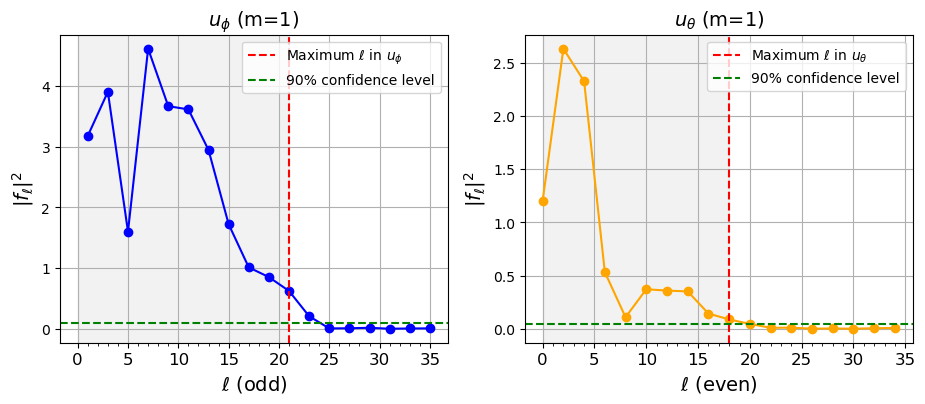

In [5]:
l_theory_cutoff = 15
l_max = 22
_, _, uphi_m1_lct_mag, uthe_m1_lct_mag, uphi_m1_err_r_lct_mag, uphi_m1_err_i_lct_mag, uthe_m1_err_r_lct_mag, uthe_m1_err_i_lct_mag, uphi_m1_err_samples_real, uphi_m1_err_samples_imag, uthe_m1_err_samples_real, uthe_m1_err_samples_imag  = project_onto_legendre(1, uphi_m1_lct_mag, uthe_m1_lct_mag, lats, symmetryuphi='anti', l_max=l_max, l_theory_cutoff=l_theory_cutoff, noise_factor=3, num_mc_samples=500, error_method='monte_carlo')


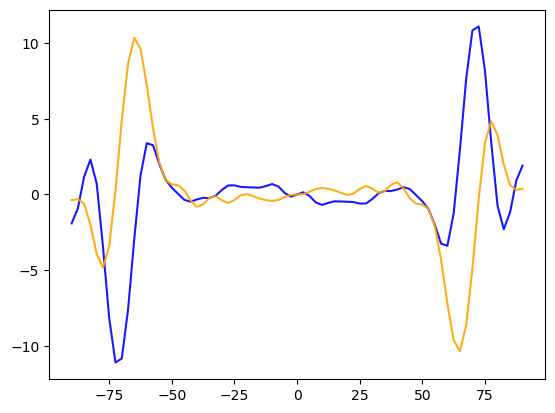

In [8]:
plt.plot(lats, uphi_m1_lct_mag.real + uphi_m1_err_samples_real[100], color='blue', alpha=0.9)
plt.plot(lats, uphi_m1_lct_mag.imag + uphi_m1_err_samples_imag[100], color='orange', alpha=0.9)